## Python statistics essential training - 05_06_bayesian

Standard imports

In [1]:
import math

In [2]:
import numpy as np
import pandas as pd

In [3]:
import matplotlib
import matplotlib.pyplot as pp

In [4]:
%matplotlib inline

In [6]:
import pymc as pm

/home/bluesanta/jupyterlab/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [7]:
n = 100
k = 61

with pm.Model() as coin_context:
    p = pm.Uniform('p', 0.40, 0.80)

    y = pm.Binomial('y', n=n, p=p, observed=k)

    trace = pm.sample(10000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 1 seconds.


In [8]:
pm.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.608,0.048,0.521,0.7,0.0,0.0,16689.0,25742.0,1.0


array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

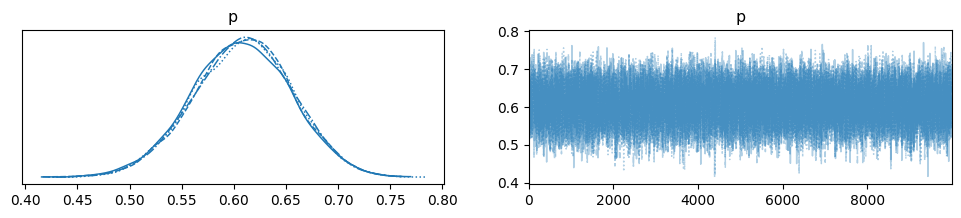

In [10]:
import arviz as az
az.plot_trace(trace)

In [11]:
gdata=pd.read_csv('gapminder.csv').query('year == 1985')

In [12]:
gdata.sort_values('age5_surviving',inplace=True)

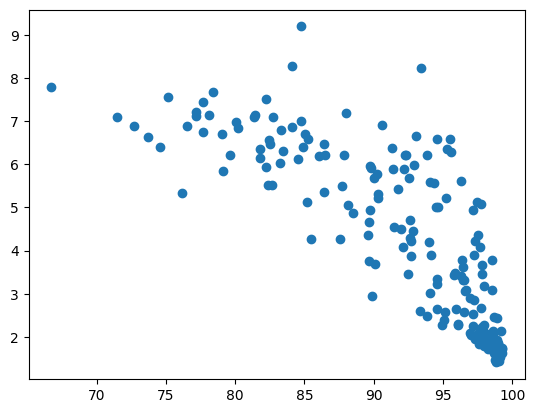

In [13]:
pp.scatter(gdata['age5_surviving'],gdata['babies_per_woman'])

In [16]:
with pm.Model() as gapminder_context:
    intercept = pm.Uniform('intercept',5,15)
    slope = pm.Uniform('slope',-1,1)
    
    babies = pm.Normal('babies',
                       mu = intercept + slope * (gdata['age5_surviving'] - 65),
                       sigma = 1,
                       observed = gdata['babies_per_woman'])
    
    trace = pm.sample(10000)

Initializing NUTS using jitter+adapt_diag...
/home/bluesanta/jupyterlab/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 2 seconds.


In [17]:
pm.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,10.193,0.275,9.665,10.706,0.003,0.002,7238.0,8542.0,1.0
slope,-0.219,0.010,-0.238,-0.200,0.000,0.000,7200.0,8857.0,1.0


array([[<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'intercept'}>],
       [<Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'slope'}>]], dtype=object)

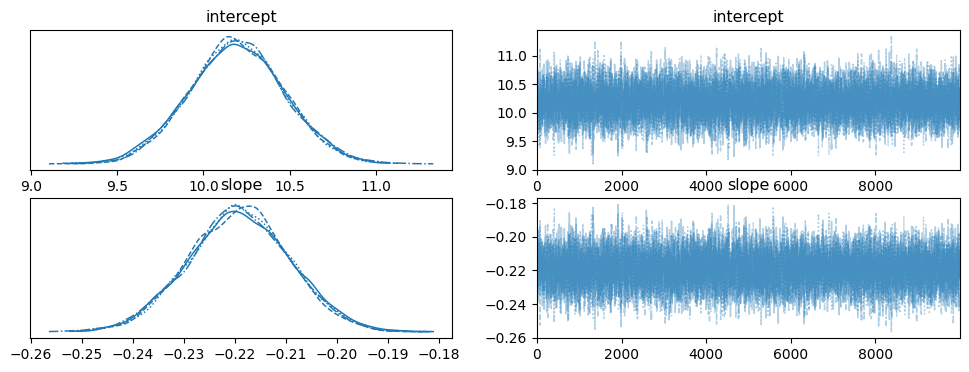

In [20]:
az.plot_trace(trace)

In [25]:
intercept_mean = float(trace.posterior['intercept'].mean())
slope_mean = float(trace.posterior['slope'].mean())

babies = intercept_mean + slope_mean * (gdata['age5_surviving'] - 65)

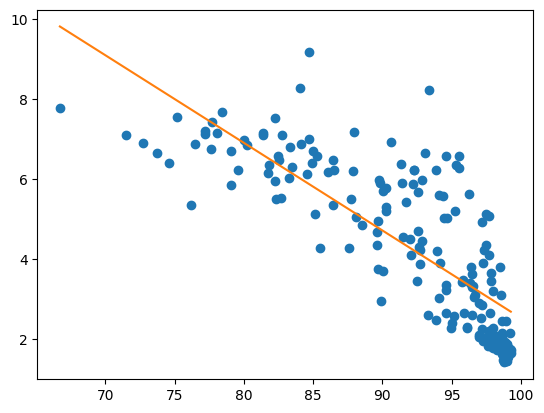

In [26]:
pp.scatter(gdata['age5_surviving'],gdata['babies_per_woman'])
pp.plot(gdata['age5_surviving'],babies,'C1')

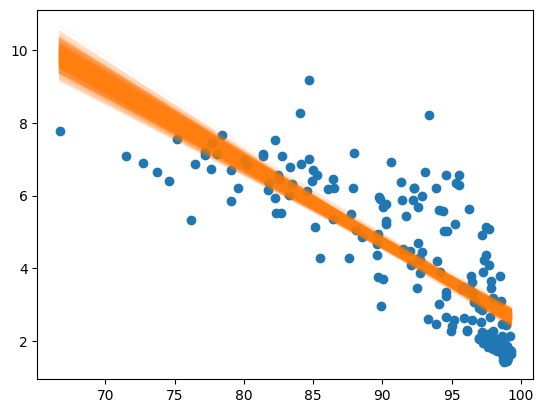

In [31]:
pp.scatter(gdata['age5_surviving'],gdata['babies_per_woman'])

intercepts = trace.posterior['intercept'].values.flatten()
slopes = trace.posterior['slope'].values.flatten()

for intercept, slope in zip(intercepts[::50],slopes[::50]):
    babies = intercept + slope * (gdata['age5_surviving'] - 65)
    pp.plot(gdata['age5_surviving'],babies,'C1',alpha=0.05)